# Modelagem de Sobrevida - LUSC

## Imports

In [1]:
!pip install numpy pandas matplotlib scikit-learn lifelines scikit-survival torchtuples pycox openpyxl

In [2]:
from pathlib import Path
from itertools import product
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import t

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

from lifelines import CoxPHFitter, WeibullAFTFitter
from lifelines.utils import concordance_index

from sksurv.util import Surv
from sksurv.ensemble import RandomSurvivalForest, GradientBoostingSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

import torch
import torchtuples as tt
from pycox.models import CoxPH, DeepHitSingle
from pycox.evaluation import EvalSurv

## Settings

In [3]:
cohort = "LUSC"

project_dir = Path("..").resolve()

data_path = project_dir / "data" / "processed" / "lusc" / "lusc_integrated_full.csv"

results_dir = project_dir / "reports" / "results" / "lusc"
figures_dir = project_dir / "reports" / "figures" / "lusc"

results_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

time_col = "surv__OS.time"
event_col = "surv__OS"

seed = 42
n_splits = 5

In [4]:
print(data_path)

df = pd.read_csv(data_path, sep=";")

print("Shape:", df.shape)
df.head()

C:\Users\Sergio Rodrigues\OneDrive\Documentos\TCC - Ana Clara Rodrigues\Final\An-lise-de-Sobrevida\data\processed\lusc\lusc_integrated_full.csv
Shape: (494, 20576)


,patient_id,surv__OS.time,surv__OS,clin__age_at_initial_pathologic_diagnosis,clin__number_pack_years_smoked,clin__tobacco_smoking_history,clin__age_at_initial_pathologic_diagnosis_missing,clin__number_pack_years_smoked_missing,clin__tobacco_smoking_history_missing,clin__gender_bin,...,TULP2,NPY5R,GNGT2,GNGT1,TULP3,PTRF,BCL6B,GSTK1,SELP,SELS
0,TCGA-18-3406,371.0,1,67.0,200.0,4.0,0,0,0,1,...,0.8379,1.3645,5.4173,6.8770,8.6783,10.8793,7.2645,10.5071,6.8770,10.8624
1,TCGA-18-3407,136.0,1,72.0,40.0,3.0,0,0,0,1,...,0.5614,0.0000,3.7408,2.9374,8.6306,12.4955,8.0396,10.7039,6.9061,10.5319
2,TCGA-18-3408,2304.0,1,77.0,30.0,4.0,0,0,0,0,...,1.1286,0.0000,4.9101,3.4705,8.9517,11.5836,6.8141,10.7232,6.9587,10.6149
3,TCGA-18-3409,3747.0,0,74.0,20.0,3.0,0,0,0,1,...,1.6094,2.4894,4.8166,1.0183,9.5472,13.0532,8.3195,10.3556,6.7297,10.0400
4,TCGA-18-3410,146.0,1,81.0,0.0,3.0,0,1,0,1,...,0.8382,0.4791,5.0053,4.2569,10.0043,9.9764,7.1216,9.9741,5.9462,10.4818


In [5]:
if "patient_id" in df.columns:
    patient_ids = df["patient_id"].copy()
    df = df.drop(columns=["patient_id"])
else:
    patient_ids = pd.Series(range(len(df)), name="patient_id")

In [6]:
for col in df.columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Total de nulos:", int(df.isna().sum().sum()))

nulos = df.isna().sum().sort_values(ascending=False)
nulos[nulos > 0].head(30)

Total de nulos: 0


Series([], dtype: int64)

In [7]:
df[event_col] = df[event_col].astype(int)
df[time_col] = df[time_col].astype(float)

print(df[event_col].value_counts())

print( round(df[event_col].mean() * 100, 2), "%")

print("Mínimo:", df[time_col].min())
print("Mediana:", df[time_col].median())
print("Máximo:", df[time_col].max())

surv__OS
0    282
1    212
Name: count, dtype: int64
42.91 %
Mínimo: 1.0
Mediana: 663.0
Máximo: 5287.0


In [8]:
# Assinatura imune 10 genes
genes_lusc_10 = [
    "CALCB", "GCGR", "HTR3A", "AMH", "VGF",
    "SEMA3B", "NRTN", "ENG", "ACVRL1", "NR4A1"
]

# Assinatura imune 13 genes
genes_lusc_13 = [
    "FGF4", "FGL1", "LIM2", "NPY", "F13A1",
    "CDH12", "CD1E", "OTX2", "ADRA1D",
    "SAMD9L", "ZFP42", "GAGE2A", "KLRC2"
]

# Assinatura glicolítica 3 genes
genes_lusc_glicolise = [
    "HKDC1", "ALDH7A1", "MDH1"
]

# Assinatura prognóstica NSCLC
genes_nsclc = [
    "ABCC4", "CCL19", "SLC39A8", "CD27",
    "FUT7", "DAG1", "ZNF71"
]

# Drivers clássicos de LUSC
genes_lusc_drivers = [
    "TP53", "CDKN2A", "PTEN", "PIK3CA", "KEAP1",
    "NFE2L2", "NOTCH1", "RB1", "SOX2", "TP63", "FGFR1"
]

genes_literatura = (
    genes_lusc_10
    + genes_lusc_13
    + genes_lusc_glicolise
    + genes_nsclc
    + genes_lusc_drivers
)

genes_literatura = [str(g).replace("\u200b", "").strip() for g in genes_literatura]
genes_literatura = list(dict.fromkeys(genes_literatura))

genes_candidatos = [g for g in genes_literatura if g in df.columns]
genes_ausentes = [g for g in genes_literatura if g not in df.columns]


In [9]:
clin_cols = [
    c for c in df.columns
    if c.startswith("clin__")
    and c not in [time_col, event_col]
    and "vital_status" not in c.lower()
]

feature_cols = clin_cols + genes_candidatos
feature_cols = list(dict.fromkeys(feature_cols))

X = df[feature_cols].copy()
tempo = df[time_col].copy()
evento = df[event_col].copy()

mask_valid_survival = (
    tempo.notna()
    & evento.notna()
    & np.isfinite(tempo)
    & (tempo > 0)
)

X = X.loc[mask_valid_survival].copy()
tempo = tempo.loc[mask_valid_survival].astype(float).copy()
evento = evento.loc[mask_valid_survival].astype(int).copy()

print("Pacientes após filtro de sobrevida:", X.shape[0])
print("Colunas clínicas:", len(clin_cols))
print("Genes candidatos presentes:", len(genes_candidatos))
print(genes_candidatos)
print("Genes candidatos ausentes:", len(genes_ausentes))
print(genes_ausentes)
print("Total de features antes da seleção por fold:", X.shape[1])


Pacientes após filtro de sobrevida: 494
Colunas clínicas: 43
Genes candidatos presentes: 44
['CALCB', 'GCGR', 'HTR3A', 'AMH', 'VGF', 'SEMA3B', 'NRTN', 'ENG', 'ACVRL1', 'NR4A1', 'FGF4', 'FGL1', 'LIM2', 'NPY', 'F13A1', 'CDH12', 'CD1E', 'OTX2', 'ADRA1D', 'SAMD9L', 'ZFP42', 'GAGE2A', 'KLRC2', 'HKDC1', 'ALDH7A1', 'MDH1', 'ABCC4', 'CCL19', 'SLC39A8', 'CD27', 'FUT7', 'DAG1', 'ZNF71', 'TP53', 'CDKN2A', 'PTEN', 'PIK3CA', 'KEAP1', 'NFE2L2', 'NOTCH1', 'RB1', 'SOX2', 'TP63', 'FGFR1']
Genes candidatos ausentes: 0
[]
Total de features antes da seleção por fold: 87


In [10]:
skf = StratifiedKFold(
    n_splits=n_splits,
    shuffle=True,
    random_state=seed
)

folds = list(skf.split(X, evento))

print("Quantidade de folds:", len(folds))

for i, (train_idx, test_idx) in enumerate(folds, start=1):
    print(
        f"Fold {i}:",
        "treino =", len(train_idx),
        "| teste =", len(test_idx),
        "| eventos teste =", int(evento.iloc[test_idx].sum())
    )

Quantidade de folds: 5
Fold 1: treino = 395 | teste = 99 | eventos teste = 43
Fold 2: treino = 395 | teste = 99 | eventos teste = 43
Fold 3: treino = 395 | teste = 99 | eventos teste = 42
Fold 4: treino = 395 | teste = 99 | eventos teste = 42
Fold 5: treino = 396 | teste = 98 | eventos teste = 42


## Pré-processamento nos folds

In [11]:
def variancia(X_train, X_test, threshold=0.01):
    seletor = VarianceThreshold(threshold=threshold)

    X_train_sel = seletor.fit_transform(X_train)
    X_test_sel = seletor.transform(X_test)

    colunas_ok = X_train.columns[seletor.get_support()]
    colunas_removidas = X_train.columns[~seletor.get_support()].tolist()

    X_train_sel = pd.DataFrame(X_train_sel, columns=colunas_ok, index=X_train.index)
    X_test_sel = pd.DataFrame(X_test_sel, columns=colunas_ok, index=X_test.index)

    return X_train_sel, X_test_sel, colunas_removidas

In [12]:
def colinearidade(X_train, X_test, limite=0.90):
    corr = X_train.corr().abs()
    matriz_superior = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

    colunas_remover = [
        col for col in matriz_superior.columns
        if any(matriz_superior[col] > limite)
    ]

    X_train_ok = X_train.drop(columns=colunas_remover, errors="ignore")
    X_test_ok = X_test.drop(columns=colunas_remover, errors="ignore")

    return X_train_ok, X_test_ok, colunas_remover

In [13]:
def padronizar(X_train, X_test):
    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
    X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

    return X_train_scaled, X_test_scaled

In [14]:
def verificar_matriz(X_train, X_test):
    if X_train.shape[1] == 0:
        raise ValueError("Nenhuma variável ficou disponível depois do pré-processamento.")

    if X_train.isna().sum().sum() > 0 or X_test.isna().sum().sum() > 0:
        raise ValueError("Ainda existem nulos depois do pré-processamento.")

    if not np.isfinite(X_train.to_numpy()).all() or not np.isfinite(X_test.to_numpy()).all():
        raise ValueError("Ainda existem valores infinitos depois do pré-processamento.")


In [15]:
def fold_p(X_train, X_test, usar_scaler=True, var_threshold=0.01, corr_threshold=0.90):
    X_train_prep, X_test_prep, removidas_var = variancia(
        X_train,
        X_test,
        threshold=var_threshold
    )

    X_train_prep, X_test_prep, removidas_corr = colinearidade(
        X_train_prep,
        X_test_prep,
        limite=corr_threshold
    )

    if usar_scaler:
        X_train_prep, X_test_prep = padronizar(X_train_prep, X_test_prep)

    verificar_matriz(X_train_prep, X_test_prep)

    info = {
        "baixa_variancia": removidas_var,
        "clin_baixa_variancia": [c for c in removidas_var if c.startswith("clin__")],
        "genes_baixa_variancia": [c for c in removidas_var if not c.startswith("clin__")],
        "colinearidade": removidas_corr,
        "clin_colinearidade": [c for c in removidas_corr if c.startswith("clin__")],
        "genes_colinearidade": [c for c in removidas_corr if not c.startswith("clin__")],
    }

    return X_train_prep, X_test_prep, info

In [16]:
def y_sksurv(tempo_parte, evento_parte):
    return Surv.from_arrays(
        event=evento_parte.astype(bool).values,
        time=tempo_parte.astype(float).values
    )

In [17]:
def selecionar_genes(X_train, tempo_train, evento_train, genes_candidatos, p_limite=0.05):
    linhas = []

    for gene in genes_candidatos:
        if gene not in X_train.columns:
            continue

        tmp = pd.DataFrame({
            "tempo": tempo_train.values,
            "evento": evento_train.values,
            gene: X_train[gene].values
        }).dropna()

        if tmp.shape[0] < 20 or tmp[gene].nunique() < 2:
            continue

        desvio = tmp[gene].std()
        if desvio == 0 or pd.isna(desvio):
            continue

        tmp[gene] = (tmp[gene] - tmp[gene].mean()) / desvio

        try:
            cph_uni = CoxPHFitter()
            cph_uni.fit(tmp, duration_col="tempo", event_col="evento")
            s = cph_uni.summary.loc[gene]

            linhas.append({
                "gene": gene,
                "coef": s["coef"],
                "HR": s["exp(coef)"],
                "p": s["p"]
            })
        except Exception:
            continue

    tabela = pd.DataFrame(linhas)

    if tabela.empty:
        return [], tabela

    tabela = tabela.sort_values("p").reset_index(drop=True)
    genes_fold = tabela.loc[tabela["p"] < p_limite, "gene"].tolist()

    return genes_fold, tabela

In [18]:
def x_fold(X_train, X_test, tempo_train, evento_train, verbose=True):
    genes_fold, tabela_genes = selecionar_genes(
        X_train=X_train,
        tempo_train=tempo_train,
        evento_train=evento_train,
        genes_candidatos=genes_candidatos,
        p_limite=0.05
    )

    cols_clinicas = [c for c in clin_cols if c in X_train.columns]
    cols_fold = list(dict.fromkeys(cols_clinicas + genes_fold))

    if verbose:
        print("Genes selecionados neste fold:", len(genes_fold), genes_fold)

    return X_train[cols_fold].copy(), X_test[cols_fold].copy(), genes_fold, tabela_genes

In [19]:
resultados_folds = []
resultados = {}
tuning_nested = []

In [20]:
def limpeza(nome_modelo):
    global resultados_folds, tuning_nested

    resultados_folds = [
        linha for linha in resultados_folds
        if linha["modelo"] != nome_modelo
    ]

    tuning_nested = [
        linha for linha in tuning_nested
        if linha["modelo"] != nome_modelo
    ]

    if nome_modelo in resultados:
        del resultados[nome_modelo]

In [21]:
def _resultado(modelo, fold, c_train, c_test, genes_fold=None, hiperparametros="", info=None):
    genes_fold = genes_fold or []
    info = info or {}

    resultados_folds.append({
        "coorte": cohort,
        "modelo": modelo,
        "fold": fold,
        "c_index_train": c_train,
        "c_index_test": c_test,
        "gap": c_train - c_test,
        "n_genes_fold": len(genes_fold),
        "genes_fold": ", ".join(genes_fold),
        "hiperparametros_fold": hiperparametros,
        "n_baixa_variancia": len(info.get("baixa_variancia", [])),
        "n_clin_baixa_variancia": len(info.get("clin_baixa_variancia", [])),
        "n_colinearidade": len(info.get("colinearidade", [])),
        "n_clin_colinearidade": len(info.get("clin_colinearidade", [])),
    })

In [22]:
def resultados_(nome_modelo):
    temp = pd.DataFrame(resultados_folds)
    temp = temp[temp["modelo"] == nome_modelo]

    resultado = {
        "coorte": cohort,
        "modelo": nome_modelo,
        "c_index_treino_medio": temp["c_index_train"].mean(),
        "c_index_teste_medio": temp["c_index_test"].mean(),
        "dp_teste": temp["c_index_test"].std(),
        "gap_medio": temp["gap"].mean()
    }

    resultados[nome_modelo] = resultado
    return pd.DataFrame([resultado])

## Tuning aninhado dos hiperparâmetros

In [23]:
param_grid_cox = {
    "penalizer": [0.1, 1.0, 10.0]
}

param_grid_weibull = {
    "penalizer": [0.1, 1.0, 10.0]
}

param_grid_rsf = {
    "n_estimators": [100, 200],
    "min_samples_split": [15, 25],
    "min_samples_leaf": [10, 20],
    "max_features": ["sqrt", 5]
}

param_grid_gbsa = {
    "n_estimators": [100, 150],
    "learning_rate": [0.01, 0.02],
    "max_depth": [1, 2],
    "subsample": [0.7]
}


## Funções

In [24]:
def grid_params(param_grid):
    chaves = list(param_grid.keys())
    valores = [param_grid[chave] for chave in chaves]
    return [dict(zip(chaves, item)) for item in product(*valores)]


def params_txt(params):
    return "; ".join([f"{chave}={valor}" for chave, valor in params.items()])


def ajustar_params(params, n_features):
    params = params.copy()

    if "max_features" in params:
        valor = params["max_features"]
        if isinstance(valor, int) and valor > n_features:
            params["max_features"] = n_features

    return params


def arrumar_pred_tempo(pred):
    pred = pd.Series(np.asarray(pred).ravel()).replace([np.inf, -np.inf], np.nan)

    if pred.notna().sum() == 0:
        pred = pd.Series(np.ones(len(pred)), index=pred.index)
    else:
        pred = pred.fillna(pred.max())

    return pred

In [25]:
def score_classico(nome_modelo, params, X_train, X_out, tempo_train, tempo_out, evento_train, evento_out, random_state=None):
    params = ajustar_params(params, n_features=X_train.shape[1])
    random_state = seed if random_state is None else random_state

    if nome_modelo == "CoxPH":
        df_train = X_train.copy()
        df_train[time_col] = tempo_train.values
        df_train[event_col] = evento_train.values

        modelo = CoxPHFitter(**params)
        modelo.fit(df_train, duration_col=time_col, event_col=event_col)

        risco_out = modelo.predict_partial_hazard(X_out)
        c_out = concordance_index(tempo_out, -risco_out, evento_out)

    elif nome_modelo == "Weibull AFT":
        df_train = X_train.copy()
        df_train[time_col] = tempo_train.values
        df_train[event_col] = evento_train.values

        modelo = WeibullAFTFitter(**params)
        modelo.fit(df_train, duration_col=time_col, event_col=event_col)

        pred_out = arrumar_pred_tempo(modelo.predict_median(X_out))
        c_out = concordance_index(tempo_out, pred_out, evento_out)

    elif nome_modelo == "RSF":
        y_train = y_sksurv(tempo_train, evento_train)

        modelo = RandomSurvivalForest(
            **params,
            n_jobs=-1,
            random_state=random_state
        )
        modelo.fit(X_train, y_train)

        risco_out = modelo.predict(X_out)
        c_out = concordance_index_censored(
            evento_out.astype(bool),
            tempo_out,
            risco_out
        )[0]

    elif nome_modelo == "GBSA":
        y_train = y_sksurv(tempo_train, evento_train)

        modelo = GradientBoostingSurvivalAnalysis(
            **params,
            random_state=random_state
        )
        modelo.fit(X_train, y_train)

        risco_out = modelo.predict(X_out)
        c_out = concordance_index_censored(
            evento_out.astype(bool),
            tempo_out,
            risco_out
        )[0]

    else:
        raise ValueError(f"Modelo não reconhecido: {nome_modelo}")

    return c_out


In [26]:
def score_no_val(nome_modelo, params, X_train_raw, X_val_raw, tempo_train, tempo_val, evento_train, evento_val, usar_scaler, random_state=None):
    try:
        X_train_sel, X_val_sel, genes_fold, _ = x_fold(
            X_train=X_train_raw,
            X_test=X_val_raw,
            tempo_train=tempo_train,
            evento_train=evento_train,
            verbose=False
        )

        X_train_prep, X_val_prep, _ = fold_p(
            X_train_sel,
            X_val_sel,
            usar_scaler=usar_scaler,
            var_threshold=0.01,
            corr_threshold=0.90
        )

        c_val = score_classico(
            nome_modelo=nome_modelo,
            params=params,
            X_train=X_train_prep,
            X_out=X_val_prep,
            tempo_train=tempo_train,
            tempo_out=tempo_val,
            evento_train=evento_train,
            evento_out=evento_val,
            random_state=random_state
        )

        return c_val, len(genes_fold)

    except Exception:
        return np.nan, np.nan

In [27]:
def tuning_int(nome_modelo, param_grid, X_outer_train, tempo_outer_train, evento_outer_train, usar_scaler, fold_externo, n_splits_inner=3):
    inner_cv = StratifiedKFold(
        n_splits=n_splits_inner,
        shuffle=True,
        random_state=seed + fold_externo
    )

    linhas = []
    combinacoes = grid_params(param_grid)

    for params in combinacoes:
        for inner_fold, (idx_train, idx_val) in enumerate(inner_cv.split(X_outer_train, evento_outer_train), start=1):
            X_inner_train = X_outer_train.iloc[idx_train].copy()
            X_inner_val = X_outer_train.iloc[idx_val].copy()

            tempo_inner_train = tempo_outer_train.iloc[idx_train]
            tempo_inner_val = tempo_outer_train.iloc[idx_val]

            evento_inner_train = evento_outer_train.iloc[idx_train]
            evento_inner_val = evento_outer_train.iloc[idx_val]

            c_val, n_genes = score_no_val(
                nome_modelo=nome_modelo,
                params=params,
                X_train_raw=X_inner_train,
                X_val_raw=X_inner_val,
                tempo_train=tempo_inner_train,
                tempo_val=tempo_inner_val,
                evento_train=evento_inner_train,
                evento_val=evento_inner_val,
                usar_scaler=usar_scaler,
                random_state=seed + 100 * fold_externo + inner_fold
            )

            linhas.append({
                "coorte": cohort,
                "modelo": nome_modelo,
                "fold_externo": fold_externo,
                "fold_interno": inner_fold,
                "parametros": params_txt(params),
                "c_index_validacao_interna": c_val,
                "n_genes_inner": n_genes
            })

    tabela_tuning = pd.DataFrame(linhas)

    resultado_params = (
        tabela_tuning
        .groupby(["coorte", "modelo", "fold_externo", "parametros"], as_index=False)
        .agg(
            c_index_validacao_interna_medio=("c_index_validacao_interna", "mean"),
            c_index_validacao_interna_dp=("c_index_validacao_interna", "std"),
            n_genes_inner_medio=("n_genes_inner", "mean")
        )
        .sort_values("c_index_validacao_interna_medio", ascending=False)
        .reset_index(drop=True)
    )

    melhor_texto = resultado_params.iloc[0]["parametros"]
    melhor_params = next(params for params in combinacoes if params_txt(params) == melhor_texto)

    tuning_nested.extend(linhas)

    return melhor_params, resultado_params

In [28]:
def resultado_class(nome_modelo, params, X_train, X_test, tempo_train, tempo_test, evento_train, evento_test, random_state=None):
    """Aqui o modelo final é treinado uma vez só no treino externo e avaliado em treino/teste."""
    params = ajustar_params(params, n_features=X_train.shape[1])
    random_state = seed if random_state is None else random_state

    if nome_modelo == "CoxPH":
        df_train = X_train.copy()
        df_train[time_col] = tempo_train.values
        df_train[event_col] = evento_train.values

        modelo = CoxPHFitter(**params)
        modelo.fit(df_train, duration_col=time_col, event_col=event_col)

        risco_train = modelo.predict_partial_hazard(X_train)
        risco_test = modelo.predict_partial_hazard(X_test)

        c_train = concordance_index(tempo_train, -risco_train, evento_train)
        c_test = concordance_index(tempo_test, -risco_test, evento_test)

    elif nome_modelo == "Weibull AFT":
        df_train = X_train.copy()
        df_train[time_col] = tempo_train.values
        df_train[event_col] = evento_train.values

        modelo = WeibullAFTFitter(**params)
        modelo.fit(df_train, duration_col=time_col, event_col=event_col)

        pred_train = arrumar_pred_tempo(modelo.predict_median(X_train))
        pred_test = arrumar_pred_tempo(modelo.predict_median(X_test))

        c_train = concordance_index(tempo_train, pred_train, evento_train)
        c_test = concordance_index(tempo_test, pred_test, evento_test)

    elif nome_modelo == "RSF":
        y_train = y_sksurv(tempo_train, evento_train)

        modelo = RandomSurvivalForest(
            **params,
            n_jobs=-1,
            random_state=random_state
        )
        modelo.fit(X_train, y_train)

        risco_train = modelo.predict(X_train)
        risco_test = modelo.predict(X_test)

        c_train = concordance_index_censored(
            evento_train.astype(bool),
            tempo_train,
            risco_train
        )[0]

        c_test = concordance_index_censored(
            evento_test.astype(bool),
            tempo_test,
            risco_test
        )[0]

    elif nome_modelo == "GBSA":
        y_train = y_sksurv(tempo_train, evento_train)

        modelo = GradientBoostingSurvivalAnalysis(
            **params,
            random_state=random_state
        )
        modelo.fit(X_train, y_train)

        risco_train = modelo.predict(X_train)
        risco_test = modelo.predict(X_test)

        c_train = concordance_index_censored(
            evento_train.astype(bool),
            tempo_train,
            risco_train
        )[0]

        c_test = concordance_index_censored(
            evento_test.astype(bool),
            tempo_test,
            risco_test
        )[0]

    else:
        raise ValueError(f"Modelo não reconhecido: {nome_modelo}")

    return c_train, c_test, params

In [29]:
def final_model(
    nome_modelo,
    params,
    X_train_raw,
    X_test_raw,
    tempo_train,
    tempo_test,
    evento_train,
    evento_test,
    usar_scaler,
    genes_fold,
    n_fold
):
    X_train_prep, X_test_prep, info = fold_p(
        X_train_raw,
        X_test_raw,
        usar_scaler=usar_scaler,
        var_threshold=0.01,
        corr_threshold=0.90
    )

    c_train, c_test, params_ok = resultado_class(
        nome_modelo=nome_modelo,
        params=params,
        X_train=X_train_prep,
        X_test=X_test_prep,
        tempo_train=tempo_train,
        tempo_test=tempo_test,
        evento_train=evento_train,
        evento_test=evento_test,
        random_state=seed + n_fold
    )

    _resultado(
        modelo=nome_modelo,
        fold=n_fold,
        c_train=c_train,
        c_test=c_test,
        genes_fold=genes_fold,
        hiperparametros=params_txt(params_ok),
        info=info
    )

    return c_train, c_test, info

In [30]:
def tuning_(nome_modelo, param_grid, usar_scaler):
    limpeza(nome_modelo)

    for fold, (train_idx, test_idx) in enumerate(folds, start=1):
        print(f"{nome_modelo} - fold externo {fold}")

        X_outer_train = X.iloc[train_idx].copy()
        X_outer_test = X.iloc[test_idx].copy()

        tempo_outer_train = tempo.iloc[train_idx]
        tempo_outer_test = tempo.iloc[test_idx]

        evento_outer_train = evento.iloc[train_idx]
        evento_outer_test = evento.iloc[test_idx]

        melhor_params, resultado_params = tuning_int(
            nome_modelo=nome_modelo,
            param_grid=param_grid,
            X_outer_train=X_outer_train,
            tempo_outer_train=tempo_outer_train,
            evento_outer_train=evento_outer_train,
            usar_scaler=usar_scaler,
            fold_externo=fold,
            n_splits_inner=3
        )

        print("Melhores hiperparâmetros:", melhor_params)

        X_train_sel, X_test_sel, genes_fold, _ = x_fold(
            X_train=X_outer_train,
            X_test=X_outer_test,
            tempo_train=tempo_outer_train,
            evento_train=evento_outer_train,
            verbose=True
        )

        c_train, c_test, info = final_model(
            nome_modelo=nome_modelo,
            params=melhor_params,
            X_train_raw=X_train_sel,
            X_test_raw=X_test_sel,
            tempo_train=tempo_outer_train,
            tempo_test=tempo_outer_test,
            evento_train=evento_outer_train,
            evento_test=evento_outer_test,
            usar_scaler=usar_scaler,
            genes_fold=genes_fold,
            n_fold=fold
        )

        print("Removidas por baixa variância:", len(info["baixa_variancia"]), "| clínicas:", len(info["clin_baixa_variancia"]))
        print("Removidas por colinearidade:", len(info["colinearidade"]), "| clínicas:", len(info["clin_colinearidade"]))
        print("C-index treino:", round(c_train, 4))
        print("C-index teste:", round(c_test, 4))
        print()

    return resultados_(nome_modelo)


## Modelo 1 - Cox Proportional Hazards

In [31]:
resultado_cox = tuning_("CoxPH", param_grid_cox, usar_scaler=True)
resultado_cox

CoxPH - fold externo 1
Melhores hiperparâmetros: {'penalizer': 0.1}
Genes selecionados neste fold: 13 ['ZFP42', 'NRTN', 'ALDH7A1', 'OTX2', 'F13A1', 'MDH1', 'GCGR', 'GAGE2A', 'FGF4', 'HKDC1', 'ACVRL1', 'ZNF71', 'SEMA3B']
Removidas por baixa variância: 4 | clínicas: 4
Removidas por colinearidade: 2 | clínicas: 2
C-index treino: 0.7222
C-index teste: 0.5866

CoxPH - fold externo 2
Melhores hiperparâmetros: {'penalizer': 0.1}
Genes selecionados neste fold: 11 ['ZFP42', 'NRTN', 'ALDH7A1', 'F13A1', 'HKDC1', 'OTX2', 'GCGR', 'ACVRL1', 'SLC39A8', 'NPY', 'FGF4']
Removidas por baixa variância: 3 | clínicas: 3
Removidas por colinearidade: 2 | clínicas: 2
C-index treino: 0.7
C-index teste: 0.6478

CoxPH - fold externo 3
Melhores hiperparâmetros: {'penalizer': 1.0}
Genes selecionados neste fold: 20 ['ZFP42', 'ALDH7A1', 'ZNF71', 'ACVRL1', 'HKDC1', 'SEMA3B', 'SLC39A8', 'GCGR', 'F13A1', 'NRTN', 'NR4A1', 'TP63', 'OTX2', 'KLRC2', 'FGF4', 'FGL1', 'ENG', 'SOX2', 'MDH1', 'CALCB']
Removidas por baixa variânc

,coorte,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,LUSC,CoxPH,0.699299,0.607819,0.076271,0.09148


## Modelo 2 - Weibull AFT

In [32]:
resultado_weibull = tuning_("Weibull AFT", param_grid_weibull, usar_scaler=True)
resultado_weibull

Weibull AFT - fold externo 1
Melhores hiperparâmetros: {'penalizer': 1.0}
Genes selecionados neste fold: 13 ['ZFP42', 'NRTN', 'ALDH7A1', 'OTX2', 'F13A1', 'MDH1', 'GCGR', 'GAGE2A', 'FGF4', 'HKDC1', 'ACVRL1', 'ZNF71', 'SEMA3B']
Removidas por baixa variância: 4 | clínicas: 4
Removidas por colinearidade: 2 | clínicas: 2
C-index treino: 0.7008
C-index teste: 0.6122

Weibull AFT - fold externo 2
Melhores hiperparâmetros: {'penalizer': 0.1}
Genes selecionados neste fold: 11 ['ZFP42', 'NRTN', 'ALDH7A1', 'F13A1', 'HKDC1', 'OTX2', 'GCGR', 'ACVRL1', 'SLC39A8', 'NPY', 'FGF4']
Removidas por baixa variância: 3 | clínicas: 3
Removidas por colinearidade: 2 | clínicas: 2
C-index treino: 0.6998
C-index teste: 0.6437

Weibull AFT - fold externo 3
Melhores hiperparâmetros: {'penalizer': 10.0}
Genes selecionados neste fold: 20 ['ZFP42', 'ALDH7A1', 'ZNF71', 'ACVRL1', 'HKDC1', 'SEMA3B', 'SLC39A8', 'GCGR', 'F13A1', 'NRTN', 'NR4A1', 'TP63', 'OTX2', 'KLRC2', 'FGF4', 'FGL1', 'ENG', 'SOX2', 'MDH1', 'CALCB']
Remov

,coorte,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,LUSC,Weibull AFT,0.690572,0.611701,0.075766,0.07887


## Modelo 3 - Random Survival Forest

In [33]:
resultado_rsf = tuning_("RSF", param_grid_rsf, usar_scaler=False)
resultado_rsf

RSF - fold externo 1
Melhores hiperparâmetros: {'n_estimators': 100, 'min_samples_split': 25, 'min_samples_leaf': 10, 'max_features': 5}
Genes selecionados neste fold: 13 ['ZFP42', 'NRTN', 'ALDH7A1', 'OTX2', 'F13A1', 'MDH1', 'GCGR', 'GAGE2A', 'FGF4', 'HKDC1', 'ACVRL1', 'ZNF71', 'SEMA3B']
Removidas por baixa variância: 4 | clínicas: 4
Removidas por colinearidade: 2 | clínicas: 2
C-index treino: 0.8212
C-index teste: 0.5947

RSF - fold externo 2
Melhores hiperparâmetros: {'n_estimators': 200, 'min_samples_split': 25, 'min_samples_leaf': 20, 'max_features': 'sqrt'}
Genes selecionados neste fold: 11 ['ZFP42', 'NRTN', 'ALDH7A1', 'F13A1', 'HKDC1', 'OTX2', 'GCGR', 'ACVRL1', 'SLC39A8', 'NPY', 'FGF4']
Removidas por baixa variância: 3 | clínicas: 3
Removidas por colinearidade: 2 | clínicas: 2
C-index treino: 0.7561
C-index teste: 0.5978

RSF - fold externo 3
Melhores hiperparâmetros: {'n_estimators': 200, 'min_samples_split': 25, 'min_samples_leaf': 20, 'max_features': 'sqrt'}
Genes selecionados

,coorte,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,LUSC,RSF,0.787029,0.596968,0.06141,0.190061


## Modelo 4 - Gradient Boosting Survival Analysis

In [34]:
resultado_gbsa = tuning_("GBSA", param_grid_gbsa, usar_scaler=False)
resultado_gbsa

GBSA - fold externo 1
Melhores hiperparâmetros: {'n_estimators': 150, 'learning_rate': 0.02, 'max_depth': 2, 'subsample': 0.7}
Genes selecionados neste fold: 13 ['ZFP42', 'NRTN', 'ALDH7A1', 'OTX2', 'F13A1', 'MDH1', 'GCGR', 'GAGE2A', 'FGF4', 'HKDC1', 'ACVRL1', 'ZNF71', 'SEMA3B']
Removidas por baixa variância: 4 | clínicas: 4
Removidas por colinearidade: 2 | clínicas: 2
C-index treino: 0.7596
C-index teste: 0.527

GBSA - fold externo 2
Melhores hiperparâmetros: {'n_estimators': 150, 'learning_rate': 0.02, 'max_depth': 1, 'subsample': 0.7}
Genes selecionados neste fold: 11 ['ZFP42', 'NRTN', 'ALDH7A1', 'F13A1', 'HKDC1', 'OTX2', 'GCGR', 'ACVRL1', 'SLC39A8', 'NPY', 'FGF4']
Removidas por baixa variância: 3 | clínicas: 3
Removidas por colinearidade: 2 | clínicas: 2
C-index treino: 0.6762
C-index teste: 0.5407

GBSA - fold externo 3
Melhores hiperparâmetros: {'n_estimators': 150, 'learning_rate': 0.02, 'max_depth': 2, 'subsample': 0.7}
Genes selecionados neste fold: 20 ['ZFP42', 'ALDH7A1', 'ZNF

,coorte,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,LUSC,GBSA,0.722175,0.568553,0.076213,0.153622


## Modelo 5 - DeepSurv

In [35]:
def seed_torch(valor_seed):
    random.seed(valor_seed)
    np.random.seed(valor_seed)

    torch.manual_seed(valor_seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(valor_seed)


def preparar_dados_deep(X_train, X_test):
    x_train = X_train.astype("float32").values
    x_test = X_test.astype("float32").values
    return x_train, x_test

In [36]:
nome_modelo = "DeepSurv"
limpeza(nome_modelo)

hiperparametros_deepsurv = {
    "lr": 0.001,
    "batch_size": 32,
    "epochs": 100,
    "num_nodes": [16, 8],
    "dropout": 0.1,
    "batch_norm": False,
    "early_stopping_patience": 10
}

for fold, (train_idx, test_idx) in enumerate(folds, start=1):
    print(f"{nome_modelo} - fold {fold}")
    seed_torch(seed + fold)

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    tempo_train = tempo.iloc[train_idx].astype("float32").copy()
    tempo_test = tempo.iloc[test_idx].astype("float32").copy()

    evento_train = evento.iloc[train_idx].astype("float32").copy()
    evento_test = evento.iloc[test_idx].astype("float32").copy()

    X_train, X_test, genes_fold, _ = x_fold(
        X_train=X_train,
        X_test=X_test,
        tempo_train=tempo_train,
        evento_train=evento_train,
        verbose=True
    )

    X_train_prep, X_test_prep, info = fold_p(
        X_train,
        X_test,
        usar_scaler=True,
        var_threshold=0.01,
        corr_threshold=0.90
    )

    x_train_deep, x_test_deep = preparar_dados_deep(X_train_prep, X_test_prep)

    idx_fit, idx_val = train_test_split(
        np.arange(len(x_train_deep)),
        test_size=0.2,
        random_state=seed + fold,
        stratify=evento_train.astype("int64").values
    )

    x_fit = x_train_deep[idx_fit]
    x_val = x_train_deep[idx_val]

    tempo_fit = tempo_train.values[idx_fit]
    tempo_val = tempo_train.values[idx_val]

    evento_fit = evento_train.values[idx_fit]
    evento_val = evento_train.values[idx_val]

    net = tt.practical.MLPVanilla(
        in_features=x_train_deep.shape[1],
        num_nodes=hiperparametros_deepsurv["num_nodes"],
        out_features=1,
        batch_norm=hiperparametros_deepsurv["batch_norm"],
        dropout=hiperparametros_deepsurv["dropout"]
    )

    model = CoxPH(net, tt.optim.Adam)
    model.optimizer.set_lr(hiperparametros_deepsurv["lr"])

    callbacks = [
        tt.callbacks.EarlyStopping(
            patience=hiperparametros_deepsurv["early_stopping_patience"]
        )
    ]

    model.fit(
        x_fit,
        (tempo_fit, evento_fit),
        batch_size=hiperparametros_deepsurv["batch_size"],
        epochs=hiperparametros_deepsurv["epochs"],
        callbacks=callbacks,
        val_data=(x_val, (tempo_val, evento_val)),
        verbose=False
    )

    model.compute_baseline_hazards(
        input=x_fit,
        target=(tempo_fit, evento_fit)
    )

    surv_train = model.predict_surv_df(x_train_deep)
    surv_test = model.predict_surv_df(x_test_deep)

    ev_train = EvalSurv(surv_train, tempo_train.values, evento_train.values, censor_surv="km")
    ev_test = EvalSurv(surv_test, tempo_test.values, evento_test.values, censor_surv="km")

    c_train = ev_train.concordance_td("antolini")
    c_test = ev_test.concordance_td("antolini")

    _resultado(
        modelo=nome_modelo,
        fold=fold,
        c_train=c_train,
        c_test=c_test,
        genes_fold=genes_fold,
        hiperparametros=params_txt(hiperparametros_deepsurv),
        info=info
    )

    print("Removidas por baixa variância:", len(info["baixa_variancia"]), "| clínicas:", len(info["clin_baixa_variancia"]))
    print("Removidas por colinearidade:", len(info["colinearidade"]), "| clínicas:", len(info["clin_colinearidade"]))
    print("C-index treino:", round(c_train, 4))
    print("C-index teste:", round(c_test, 4))
    print()

resultado_deepsurv = resultados_("DeepSurv")
resultado_deepsurv


DeepSurv - fold 1
Genes selecionados neste fold: 13 ['ZFP42', 'NRTN', 'ALDH7A1', 'OTX2', 'F13A1', 'MDH1', 'GCGR', 'GAGE2A', 'FGF4', 'HKDC1', 'ACVRL1', 'ZNF71', 'SEMA3B']
Removidas por baixa variância: 4 | clínicas: 4
Removidas por colinearidade: 2 | clínicas: 2
C-index treino: 0.7536
C-index teste: 0.6198

DeepSurv - fold 2
Genes selecionados neste fold: 11 ['ZFP42', 'NRTN', 'ALDH7A1', 'F13A1', 'HKDC1', 'OTX2', 'GCGR', 'ACVRL1', 'SLC39A8', 'NPY', 'FGF4']
Removidas por baixa variância: 3 | clínicas: 3
Removidas por colinearidade: 2 | clínicas: 2
C-index treino: 0.6837
C-index teste: 0.611

DeepSurv - fold 3
Genes selecionados neste fold: 20 ['ZFP42', 'ALDH7A1', 'ZNF71', 'ACVRL1', 'HKDC1', 'SEMA3B', 'SLC39A8', 'GCGR', 'F13A1', 'NRTN', 'NR4A1', 'TP63', 'OTX2', 'KLRC2', 'FGF4', 'FGL1', 'ENG', 'SOX2', 'MDH1', 'CALCB']
Removidas por baixa variância: 2 | clínicas: 2
Removidas por colinearidade: 2 | clínicas: 2
C-index treino: 0.7479
C-index teste: 0.4923

DeepSurv - fold 4
Genes selecionados 

,coorte,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,LUSC,DeepSurv,0.720055,0.58079,0.051132,0.139265


## Modelo 6 - DeepHit

In [37]:
nome_modelo = "DeepHit"
limpeza(nome_modelo)

hiperparametros_deephit = {
    "lr": 0.001,
    "batch_size": 32,
    "epochs": 200,
    "num_nodes": [32, 16],
    "dropout": 0.1,
    "batch_norm": False,
    "alpha": 0.5,
    "sigma": 0.1,
    "num_durations": 30,
    "early_stopping_patience": 10
}

for fold, (train_idx, test_idx) in enumerate(folds, start=1):
    print(f"{nome_modelo} - fold {fold}")
    seed_torch(seed + fold)

    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    tempo_train = tempo.iloc[train_idx].astype("float32").copy()
    tempo_test = tempo.iloc[test_idx].astype("float32").copy()

    evento_train = evento.iloc[train_idx].astype("int64").copy()
    evento_test = evento.iloc[test_idx].astype("int64").copy()

    X_train, X_test, genes_fold, _ = x_fold(
        X_train=X_train,
        X_test=X_test,
        tempo_train=tempo_train,
        evento_train=evento_train,
        verbose=True
    )

    X_train_prep, X_test_prep, info = fold_p(
        X_train,
        X_test,
        usar_scaler=True,
        var_threshold=0.01,
        corr_threshold=0.90
    )

    x_train_deep, x_test_deep = preparar_dados_deep(X_train_prep, X_test_prep)

    labtrans = DeepHitSingle.label_transform(hiperparametros_deephit["num_durations"])
    y_train = labtrans.fit_transform(tempo_train.values, evento_train.values)

    idx_fit, idx_val = train_test_split(
        np.arange(len(x_train_deep)),
        test_size=0.2,
        random_state=seed + fold,
        stratify=evento_train.astype("int64").values
    )

    x_fit = x_train_deep[idx_fit]
    x_val = x_train_deep[idx_val]

    y_fit = (y_train[0][idx_fit], y_train[1][idx_fit])
    y_val = (y_train[0][idx_val], y_train[1][idx_val])

    net = tt.practical.MLPVanilla(
        in_features=x_train_deep.shape[1],
        num_nodes=hiperparametros_deephit["num_nodes"],
        out_features=labtrans.out_features,
        batch_norm=hiperparametros_deephit["batch_norm"],
        dropout=hiperparametros_deephit["dropout"]
    )

    model = DeepHitSingle(
        net,
        tt.optim.Adam,
        alpha=hiperparametros_deephit["alpha"],
        sigma=hiperparametros_deephit["sigma"],
        duration_index=labtrans.cuts
    )

    model.optimizer.set_lr(hiperparametros_deephit["lr"])

    callbacks = [
        tt.callbacks.EarlyStopping(
            patience=hiperparametros_deephit["early_stopping_patience"]
        )
    ]

    model.fit(
        x_fit,
        y_fit,
        batch_size=hiperparametros_deephit["batch_size"],
        epochs=hiperparametros_deephit["epochs"],
        callbacks=callbacks,
        val_data=(x_val, y_val),
        verbose=False
    )

    surv_train = model.predict_surv_df(x_train_deep)
    surv_test = model.predict_surv_df(x_test_deep)

    ev_train = EvalSurv(surv_train, tempo_train.values, evento_train.values, censor_surv="km")
    ev_test = EvalSurv(surv_test, tempo_test.values, evento_test.values, censor_surv="km")

    c_train = ev_train.concordance_td("antolini")
    c_test = ev_test.concordance_td("antolini")

    _resultado(
        modelo=nome_modelo,
        fold=fold,
        c_train=c_train,
        c_test=c_test,
        genes_fold=genes_fold,
        hiperparametros=params_txt(hiperparametros_deephit),
        info=info
    )

    print("Removidas por baixa variância:", len(info["baixa_variancia"]), "| clínicas:", len(info["clin_baixa_variancia"]))
    print("Removidas por colinearidade:", len(info["colinearidade"]), "| clínicas:", len(info["clin_colinearidade"]))
    print("C-index treino:", round(c_train, 4))
    print("C-index teste:", round(c_test, 4))
    print()

resultado_deephit = resultados_("DeepHit")
resultado_deephit

DeepHit - fold 1
Genes selecionados neste fold: 13 ['ZFP42', 'NRTN', 'ALDH7A1', 'OTX2', 'F13A1', 'MDH1', 'GCGR', 'GAGE2A', 'FGF4', 'HKDC1', 'ACVRL1', 'ZNF71', 'SEMA3B']
Removidas por baixa variância: 4 | clínicas: 4
Removidas por colinearidade: 2 | clínicas: 2
C-index treino: 0.6256
C-index teste: 0.4508

DeepHit - fold 2
Genes selecionados neste fold: 11 ['ZFP42', 'NRTN', 'ALDH7A1', 'F13A1', 'HKDC1', 'OTX2', 'GCGR', 'ACVRL1', 'SLC39A8', 'NPY', 'FGF4']
Removidas por baixa variância: 3 | clínicas: 3
Removidas por colinearidade: 2 | clínicas: 2
C-index treino: 0.5286
C-index teste: 0.532

DeepHit - fold 3
Genes selecionados neste fold: 20 ['ZFP42', 'ALDH7A1', 'ZNF71', 'ACVRL1', 'HKDC1', 'SEMA3B', 'SLC39A8', 'GCGR', 'F13A1', 'NRTN', 'NR4A1', 'TP63', 'OTX2', 'KLRC2', 'FGF4', 'FGL1', 'ENG', 'SOX2', 'MDH1', 'CALCB']
Removidas por baixa variância: 2 | clínicas: 2
Removidas por colinearidade: 2 | clínicas: 2
C-index treino: 0.565
C-index teste: 0.5205

DeepHit - fold 4
Genes selecionados neste

,coorte,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,LUSC,DeepHit,0.573293,0.522215,0.06309,0.051079


## Resultados e Comparações

In [39]:
cohort_lower = cohort.lower()

In [40]:
df_resultados_folds = pd.DataFrame(resultados_folds)

df_resultados_folds = (
    df_resultados_folds
    .drop_duplicates(subset=["coorte", "modelo", "fold"], keep="last")
    .sort_values(["modelo", "fold"])
    .reset_index(drop=True)
)

df_resultados_folds.to_csv(
    results_dir / f"{cohort_lower}_resultados_por_fold.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print(results_dir / f"{cohort_lower}_resultados_por_fold.csv")
df_resultados_folds


C:\Users\Sergio Rodrigues\OneDrive\Documentos\TCC - Ana Clara Rodrigues\Final\An-lise-de-Sobrevida\reports\results\lusc\lusc_resultados_por_fold.csv


,coorte,modelo,fold,c_index_train,c_index_test,gap,n_genes_fold,genes_fold,hiperparametros_fold,n_baixa_variancia,n_clin_baixa_variancia,n_colinearidade,n_clin_colinearidade
0,LUSC,CoxPH,1,0.722196,0.586648,0.135549,13,"ZFP42, NRTN, ALDH7A1, OTX2, F13A1, MDH1, GCGR,...",penalizer=0.1,4,4,2,2
1,LUSC,CoxPH,2,0.699955,0.647788,0.052166,11,"ZFP42, NRTN, ALDH7A1, F13A1, HKDC1, OTX2, GCGR...",penalizer=0.1,3,3,2,2
2,LUSC,CoxPH,3,0.715771,0.498455,0.217316,20,"ZFP42, ALDH7A1, ZNF71, ACVRL1, HKDC1, SEMA3B, ...",penalizer=1.0,2,2,2,2
3,LUSC,CoxPH,4,0.685440,0.602297,0.083143,12,"HKDC1, ALDH7A1, SEMA3B, MDH1, GCGR, FGF4, F13A...",penalizer=10.0,5,5,2,2
4,LUSC,CoxPH,5,0.673132,0.703905,-0.030773,9,"HKDC1, ZFP42, OTX2, ALDH7A1, GAGE2A, GCGR, MDH...",penalizer=10.0,9,9,1,1
5,LUSC,DeepHit,1,0.625585,0.450758,0.174827,13,"ZFP42, NRTN, ALDH7A1, OTX2, F13A1, MDH1, GCGR,...",lr=0.001; batch_size=32; epochs=200; num_nodes...,4,4,2,2
6,LUSC,DeepHit,2,0.528618,0.532038,-0.003420,11,"ZFP42, NRTN, ALDH7A1, F13A1, HKDC1, OTX2, GCGR...",lr=0.001; batch_size=32; epochs=200; num_nodes...,3,3,2,2
7,LUSC,DeepHit,3,0.565030,0.520530,0.044500,20,"ZFP42, ALDH7A1, ZNF71, ACVRL1, HKDC1, SEMA3B, ...",lr=0.001; batch_size=32; epochs=200; num_nodes...,2,2,2,2
8,LUSC,DeepHit,4,0.590513,0.487877,0.102635,12,"HKDC1, ALDH7A1, SEMA3B, MDH1, GCGR, FGF4, F13A...",lr=0.001; batch_size=32; epochs=200; num_nodes...,5,5,2,2
9,LUSC,DeepHit,5,0.556722,0.619871,-0.063149,9,"HKDC1, ZFP42, OTX2, ALDH7A1, GAGE2A, GCGR, MDH...",lr=0.001; batch_size=32; epochs=200; num_nodes...,9,9,1,1


In [41]:
def comparar_modelos(df_folds):
    base = df_folds.drop_duplicates(
        subset=["coorte", "modelo", "fold"],
        keep="last"
    )

    pivot = base.pivot(
        index="fold",
        columns="modelo",
        values="c_index_test"
    )

    linhas = []
    modelos = list(pivot.columns)

    for i in range(len(modelos)):
        for j in range(i + 1, len(modelos)):
            m1 = modelos[i]
            m2 = modelos[j]

            diff = (pivot[m1] - pivot[m2]).dropna()
            n = len(diff)

            if n < 2:
                continue

            media = diff.mean()
            sd = diff.std(ddof=1)
            se = sd / np.sqrt(n)
            tcrit = t.ppf(0.975, df=n - 1)

            ic_inf = media - tcrit * se
            ic_sup = media + tcrit * se

            linhas.append({
                "coorte": cohort,
                "modelo_1": m1,
                "modelo_2": m2,
                "dif_media_cindex": media,
                "ic95_inf": ic_inf,
                "ic95_sup": ic_sup,
                "n_folds": n,
                "interpretacao": "empate tecnico" if ic_inf <= 0 <= ic_sup else "diferenca com IC 95% sem zero"
            })

    return pd.DataFrame(linhas)


comparacoes_pareadas = comparar_modelos(df_resultados_folds)

comparacoes_pareadas.to_csv(
    results_dir / f"{cohort_lower}_comparacoes_pareadas_cindex.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print(results_dir / f"{cohort_lower}_comparacoes_pareadas_cindex.csv")
comparacoes_pareadas

C:\Users\Sergio Rodrigues\OneDrive\Documentos\TCC - Ana Clara Rodrigues\Final\An-lise-de-Sobrevida\reports\results\lusc\lusc_comparacoes_pareadas_cindex.csv


,coorte,modelo_1,modelo_2,dif_media_cindex,ic95_inf,ic95_sup,n_folds,interpretacao
0,LUSC,CoxPH,DeepHit,0.085604,0.007406,0.163802,5,diferenca com IC 95% sem zero
1,LUSC,CoxPH,DeepSurv,0.027029,-0.041270,0.095327,5,empate tecnico
2,LUSC,CoxPH,GBSA,0.039265,-0.018587,0.097118,5,empate tecnico
3,LUSC,CoxPH,RSF,0.010850,-0.022388,0.044088,5,empate tecnico
4,LUSC,CoxPH,Weibull AFT,-0.003883,-0.019778,0.012012,5,empate tecnico
5,LUSC,DeepHit,DeepSurv,-0.058575,-0.166394,0.049245,5,empate tecnico
6,LUSC,DeepHit,GBSA,-0.046338,-0.101468,0.008791,5,empate tecnico
7,LUSC,DeepHit,RSF,-0.074753,-0.140910,-0.008597,5,diferenca com IC 95% sem zero
8,LUSC,DeepHit,Weibull AFT,-0.089486,-0.173136,-0.005836,5,diferenca com IC 95% sem zero
9,LUSC,DeepSurv,GBSA,0.012236,-0.087540,0.112013,5,empate tecnico


In [42]:
df_resultado_modelos = pd.DataFrame(resultados.values())

df_resultado_modelos = (
    df_resultado_modelos
    .sort_values("c_index_teste_medio", ascending=False)
    .reset_index(drop=True)
)

df_resultado_modelos.to_csv(
    results_dir / f"{cohort_lower}_resultado_modelos.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

df_tuning_nested = pd.DataFrame(tuning_nested)

df_tuning_nested.to_csv(
    results_dir / f"{cohort_lower}_tuning_nested_interno.csv",
    index=False,
    sep=";",
    encoding="utf-8-sig"
)

print(results_dir / f"{cohort_lower}_resultado_modelos.csv")
print(results_dir / f"{cohort_lower}_tuning_nested_interno.csv")

df_resultado_modelos

C:\Users\Sergio Rodrigues\OneDrive\Documentos\TCC - Ana Clara Rodrigues\Final\An-lise-de-Sobrevida\reports\results\lusc\lusc_resultado_modelos.csv
C:\Users\Sergio Rodrigues\OneDrive\Documentos\TCC - Ana Clara Rodrigues\Final\An-lise-de-Sobrevida\reports\results\lusc\lusc_tuning_nested_interno.csv


,coorte,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,LUSC,Weibull AFT,0.690572,0.611701,0.075766,0.078870
1,LUSC,CoxPH,0.699299,0.607819,0.076271,0.091480
2,LUSC,RSF,0.787029,0.596968,0.061410,0.190061
3,LUSC,DeepSurv,0.720055,0.580790,0.051132,0.139265
4,LUSC,GBSA,0.722175,0.568553,0.076213,0.153622
5,LUSC,DeepHit,0.573293,0.522215,0.063090,0.051079


In [44]:
tabela_tcc = df_resultado_modelos.copy()

colunas_num = [
    "c_index_treino_medio",
    "c_index_teste_medio",
    "dp_teste",
    "gap_medio"
]

for col in colunas_num:
    tabela_tcc[col] = tabela_tcc[col].round(4)

tabela_tcc

,coorte,modelo,c_index_treino_medio,c_index_teste_medio,dp_teste,gap_medio
0,LUSC,Weibull AFT,0.6906,0.6117,0.0758,0.0789
1,LUSC,CoxPH,0.6993,0.6078,0.0763,0.0915
2,LUSC,RSF,0.7870,0.5970,0.0614,0.1901
3,LUSC,DeepSurv,0.7201,0.5808,0.0511,0.1393
4,LUSC,GBSA,0.7222,0.5686,0.0762,0.1536
5,LUSC,DeepHit,0.5733,0.5222,0.0631,0.0511


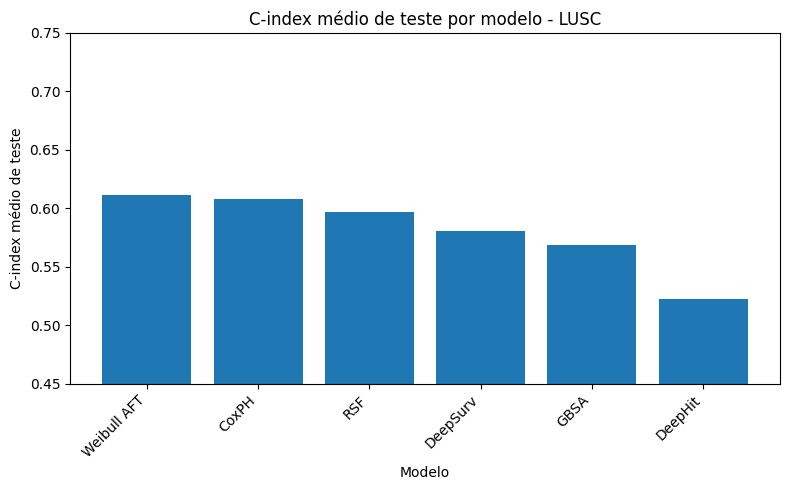

C:\Users\Sergio Rodrigues\OneDrive\Documentos\TCC - Ana Clara Rodrigues\Final\An-lise-de-Sobrevida\reports\figures\lusc\lusc_cindex_modelos.png


In [45]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    tabela_tcc["modelo"],
    tabela_tcc["c_index_teste_medio"]
)

ax.set_title(f"C-index médio de teste por modelo - {cohort}")
ax.set_xlabel("Modelo")
ax.set_ylabel("C-index médio de teste")
ax.set_ylim(0.45, 0.75)

plt.xticks(rotation=45, ha="right")
fig.tight_layout()

fig.savefig(
    figures_dir / f"{cohort_lower}_cindex_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
print(figures_dir / f"{cohort_lower}_cindex_modelos.png")

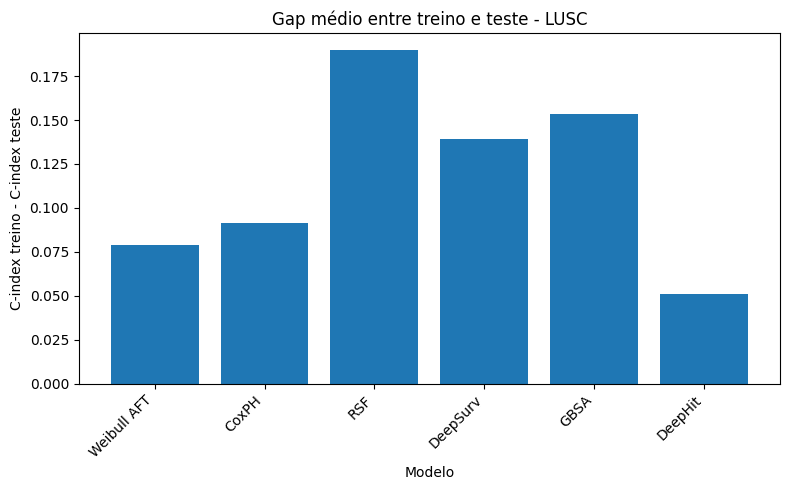

C:\Users\Sergio Rodrigues\OneDrive\Documentos\TCC - Ana Clara Rodrigues\Final\An-lise-de-Sobrevida\reports\figures\lusc\lusc_gap_modelos.png


In [46]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    tabela_tcc["modelo"],
    tabela_tcc["gap_medio"]
)

ax.set_title(f"Gap médio entre treino e teste - {cohort}")
ax.set_xlabel("Modelo")
ax.set_ylabel("C-index treino - C-index teste")

plt.xticks(rotation=45, ha="right")
fig.tight_layout()

fig.savefig(
    figures_dir / f"{cohort_lower}_gap_modelos.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
print(figures_dir / f"{cohort_lower}_gap_modelos.png")